# System Design Flowcharts

Generates flowchart images for:
- **3.7.2** Output Design
- **3.7.3** Process Design (with START / STOP)
- **3.7.5** System Flowchart

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.patches import FancyBboxPatch

# ── Colours ────────────────────────────────────────────────
C_TERMINAL  = '#A9DFBF'   # green  – START / STOP
C_PROCESS   = '#AED6F1'   # blue   – process step
C_DECISION  = '#FAD7A0'   # amber  – decision diamond
C_IO        = '#D7BDE2'   # purple – I/O block
C_OUTPUT    = '#FADBD8'   # red    – output type
C_EDGE      = '#2C3E50'
C_LABEL     = '#C0392B'
BG          = '#FDFEFE'

# ── Shape helpers ──────────────────────────────────────────
def _anchors(x, y, w, h):
    return dict(top=(x, y+h/2), bot=(x, y-h/2),
                left=(x-w/2, y), right=(x+w/2, y))

def process(ax, x, y, w, h, text, color=C_PROCESS, fs=8.5):
    ax.add_patch(FancyBboxPatch((x-w/2, y-h/2), w, h,
                                boxstyle='round,pad=0.06',
                                facecolor=color, edgecolor=C_EDGE,
                                linewidth=1.5, zorder=2))
    ax.text(x, y, text, ha='center', va='center', fontsize=fs,
            multialignment='center', zorder=3)
    return _anchors(x, y, w, h)

def terminal(ax, x, y, w, h, text, color=C_TERMINAL, fs=9):
    ax.add_patch(mpatches.Ellipse((x, y), w, h,
                                  facecolor=color, edgecolor=C_EDGE,
                                  linewidth=2, zorder=2))
    ax.text(x, y, text, ha='center', va='center', fontsize=fs,
            fontweight='bold', zorder=3)
    return _anchors(x, y, w, h)

def decision(ax, x, y, w, h, text, color=C_DECISION, fs=8.5):
    pts = np.array([[x, y+h/2], [x+w/2, y], [x, y-h/2], [x-w/2, y]])
    ax.add_patch(plt.Polygon(pts, facecolor=color, edgecolor=C_EDGE,
                             linewidth=1.5, zorder=2))
    ax.text(x, y, text, ha='center', va='center', fontsize=fs,
            multialignment='center', zorder=3)
    return _anchors(x, y, w, h)

def io_block(ax, x, y, w, h, text, color=C_IO, fs=8.5):
    sk = w * 0.09
    pts = np.array([[x-w/2+sk, y+h/2], [x+w/2+sk, y+h/2],
                    [x+w/2-sk, y-h/2], [x-w/2-sk, y-h/2]])
    ax.add_patch(plt.Polygon(pts, facecolor=color, edgecolor=C_EDGE,
                             linewidth=1.5, zorder=2))
    ax.text(x, y, text, ha='center', va='center', fontsize=fs,
            multialignment='center', zorder=3)
    return _anchors(x, y, w, h)

def arr(ax, p1, p2, label='', lx=0.18, ly=0):
    ax.annotate('', xy=p2, xytext=p1,
                arrowprops=dict(arrowstyle='->', color=C_EDGE, lw=1.5), zorder=5)
    if label:
        mx, my = (p1[0]+p2[0])/2 + lx, (p1[1]+p2[1])/2 + ly
        ax.text(mx, my, label, fontsize=8, color=C_LABEL,
                fontweight='bold', ha='center', va='center', zorder=6)

def elbow(ax, p1, p2, go_horiz_first=False):
    """L-shaped connector: two segments with arrowhead at p2."""
    if go_horiz_first:
        mid = (p2[0], p1[1])
    else:
        mid = (p1[0], p2[1])
    ax.plot([p1[0], mid[0]], [p1[1], mid[1]], color=C_EDGE, lw=1.5, zorder=4)
    ax.annotate('', xy=p2, xytext=mid,
                arrowprops=dict(arrowstyle='->', color=C_EDGE, lw=1.5), zorder=5)

def bypass(ax, p_start, p_end, x_bypass, label=''):
    """Route a line out to x_bypass, down, then back in to p_end."""
    ax.plot([p_start[0], x_bypass], [p_start[1], p_start[1]], color=C_EDGE, lw=1.5, zorder=4)
    ax.plot([x_bypass, x_bypass], [p_start[1], p_end[1]],     color=C_EDGE, lw=1.5, zorder=4)
    ax.annotate('', xy=p_end, xytext=(x_bypass, p_end[1]),
                arrowprops=dict(arrowstyle='->', color=C_EDGE, lw=1.5), zorder=5)
    if label:
        ax.text(x_bypass + 0.15, p_start[1] + 0.12, label, fontsize=8,
                color=C_LABEL, fontweight='bold', zorder=6)

def merge(ax, p_from, p_to):
    """Go straight down then across to p_to (both at same y after descent)."""
    ax.plot([p_from[0], p_from[0]], [p_from[1], p_to[1]], color=C_EDGE, lw=1.5, zorder=4)
    ax.annotate('', xy=p_to, xytext=(p_from[0], p_to[1]),
                arrowprops=dict(arrowstyle='->', color=C_EDGE, lw=1.5), zorder=5)

print('Helpers loaded.')

Helpers loaded.


---
## 3.7.2 Output Design

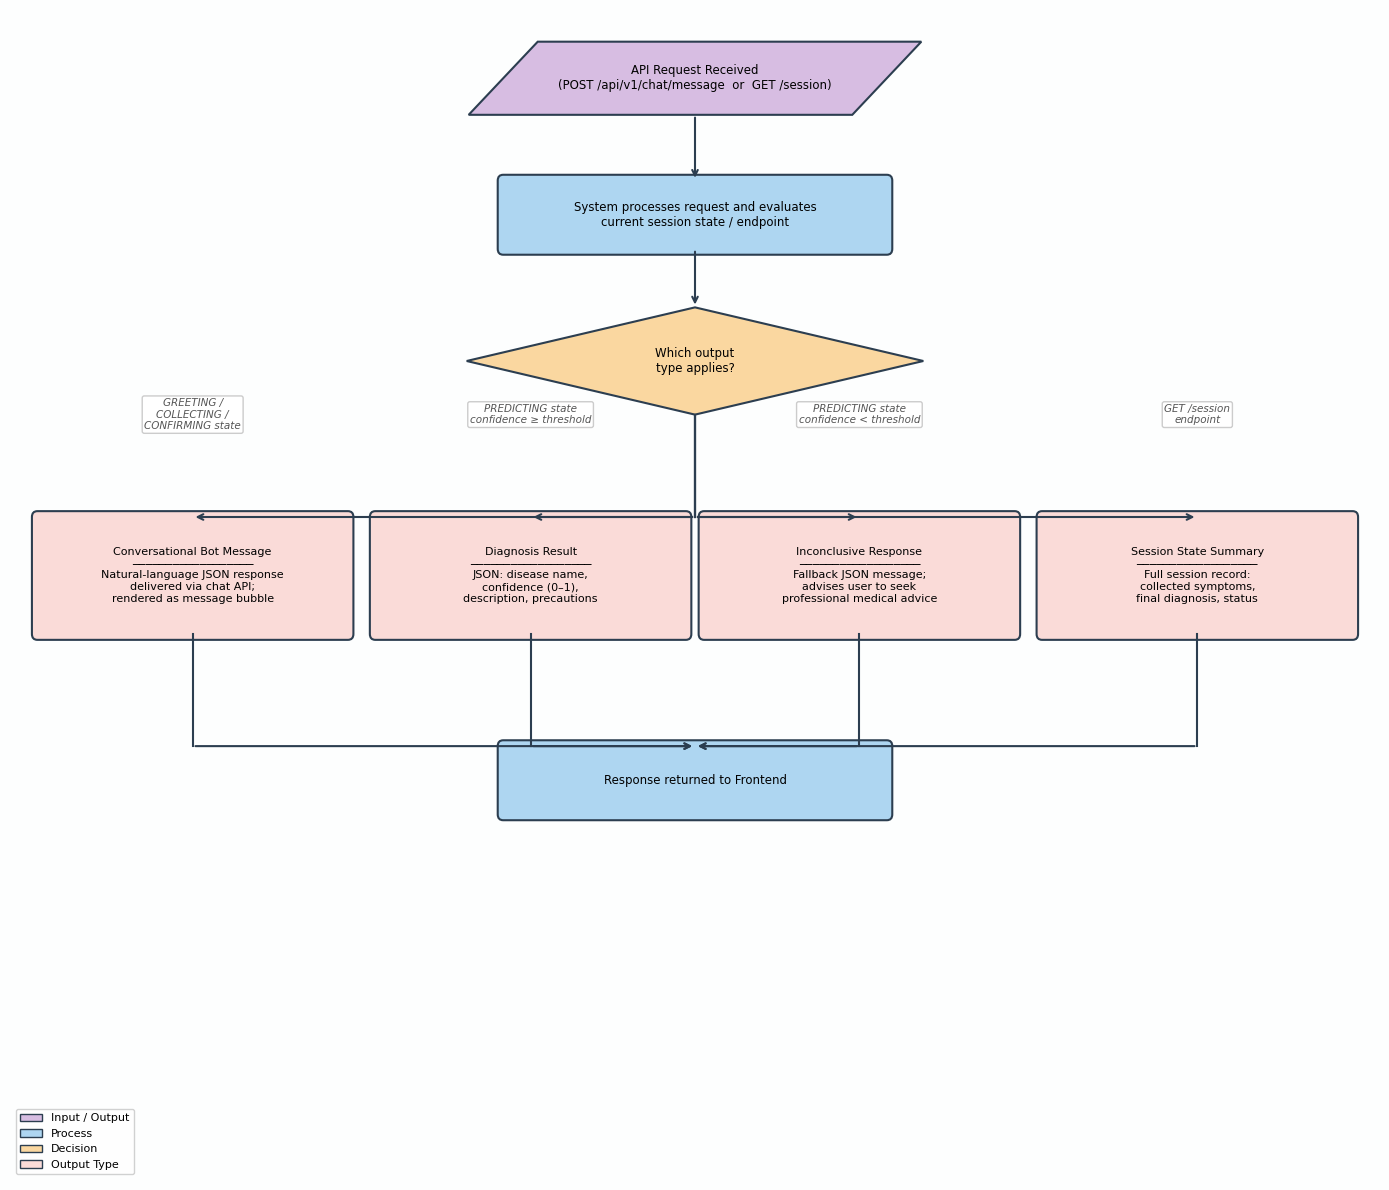

Saved: output_design_flowchart.png


In [2]:
fig, ax = plt.subplots(figsize=(14, 12))
ax.set_xlim(-7.5, 7.5)
ax.set_ylim(-6.5, 5.5)
ax.axis('off')
ax.set_facecolor(BG)
fig.patch.set_facecolor(BG)

# ── Nodes ───────────────────────────────────────────────────
n1  = io_block(ax,  0,    4.8,  4.2, 0.75,
               'API Request Received\n(POST /api/v1/chat/message  or  GET /session)')

n2  = process (ax,  0,    3.4,  4.2, 0.70,
               'System processes request and evaluates\ncurrent session state / endpoint')

n3  = decision(ax,  0,    1.9,  5.0, 1.10,
               'Which output\ntype applies?')

# Four output leaves
n_a = process (ax, -5.5, -0.3,  3.4, 1.20,
               'Conversational Bot Message\n──────────────────\nNatural-language JSON response\ndelivered via chat API;\nrendered as message bubble',
               color=C_OUTPUT, fs=8)

n_b = process (ax, -1.8, -0.3,  3.4, 1.20,
               'Diagnosis Result\n──────────────────\nJSON: disease name,\nconfidence (0–1),\ndescription, precautions',
               color=C_OUTPUT, fs=8)

n_c = process (ax,  1.8, -0.3,  3.4, 1.20,
               'Inconclusive Response\n──────────────────\nFallback JSON message;\nadvises user to seek\nprofessional medical advice',
               color=C_OUTPUT, fs=8)

n_d = process (ax,  5.5, -0.3,  3.4, 1.20,
               'Session State Summary\n──────────────────\nFull session record:\ncollected symptoms,\nfinal diagnosis, status',
               color=C_OUTPUT, fs=8)

# Condition labels above each branch
labels = [
    (-5.5, 1.35, 'GREETING /\nCOLLECTING /\nCONFIRMING state'),
    (-1.8, 1.35, 'PREDICTING state\nconfidence ≥ threshold'),
    ( 1.8, 1.35, 'PREDICTING state\nconfidence < threshold'),
    ( 5.5, 1.35, 'GET /session\nendpoint'),
]
for lx, ly, lt in labels:
    ax.text(lx, ly, lt, ha='center', va='center', fontsize=7.5,
            color='#555555', style='italic', multialignment='center',
            bbox=dict(facecolor='white', edgecolor='#cccccc', boxstyle='round,pad=0.2'))

n_merge = process(ax, 0, -2.4, 4.2, 0.70,
                  'Response returned to Frontend')

# ── Arrows ──────────────────────────────────────────────────
arr(ax, n1['bot'],  n2['top'])
arr(ax, n2['bot'],  n3['top'])

for node in [n_a, n_b, n_c, n_d]:
    elbow(ax, n3['bot'], node['top'], go_horiz_first=False)

for node in [n_a, n_b, n_c, n_d]:
    elbow(ax, node['bot'], n_merge['top'], go_horiz_first=False)

# ── Legend ──────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(facecolor=C_IO,     edgecolor=C_EDGE, label='Input / Output'),
    mpatches.Patch(facecolor=C_PROCESS,edgecolor=C_EDGE, label='Process'),
    mpatches.Patch(facecolor=C_DECISION,edgecolor=C_EDGE,label='Decision'),
    mpatches.Patch(facecolor=C_OUTPUT, edgecolor=C_EDGE, label='Output Type'),
]
ax.legend(handles=legend_items, loc='lower left', fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.savefig('output_design_flowchart.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved: output_design_flowchart.png')

---
## 3.7.3 Process Design

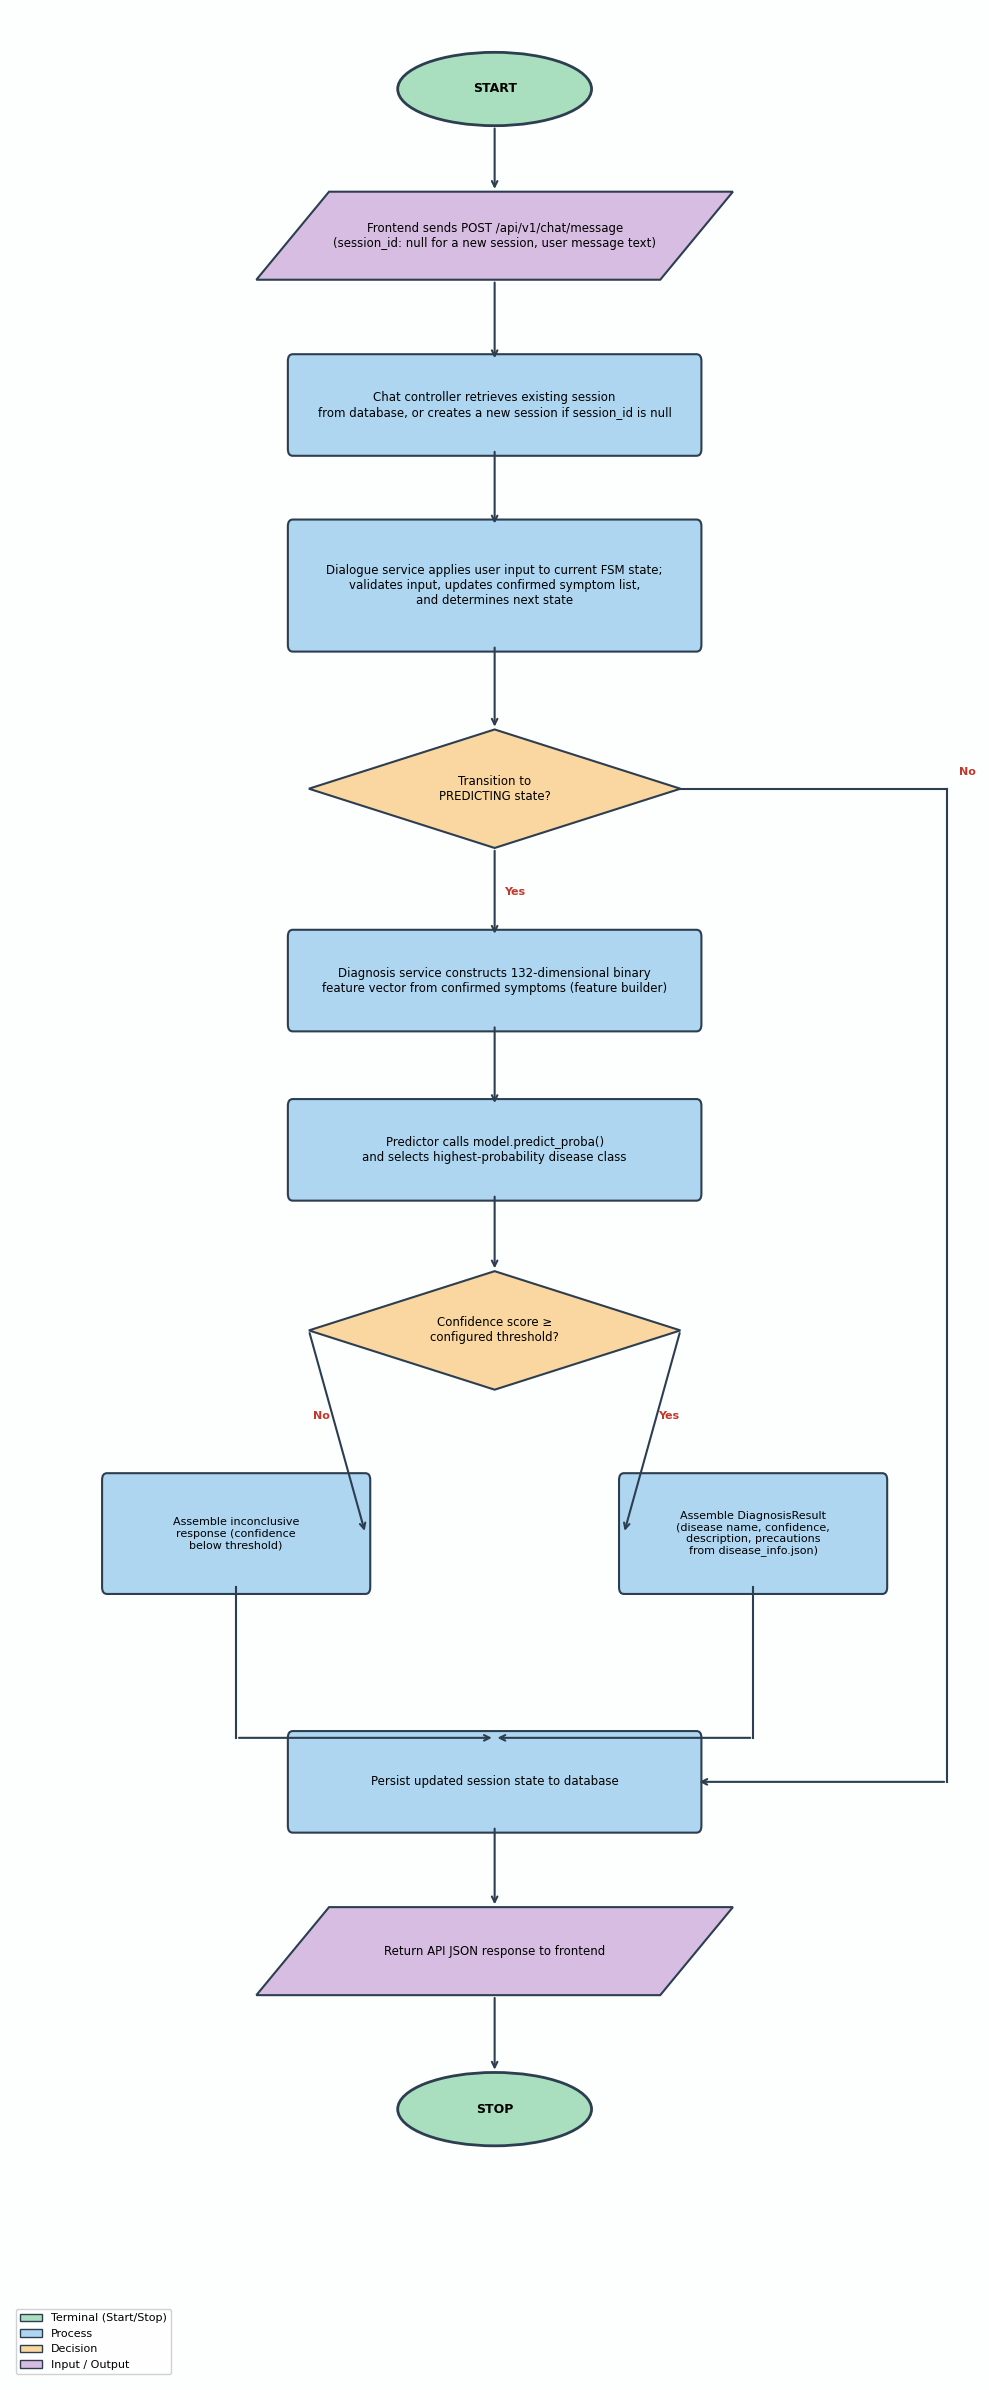

Saved: process_design_flowchart.png


In [3]:
fig, ax = plt.subplots(figsize=(10, 24))
ax.set_xlim(-6, 6)
ax.set_ylim(-8.5, 12.5)
ax.axis('off')
ax.set_facecolor(BG)
fig.patch.set_facecolor(BG)

RW, RH   = 5.0, 0.78
DW, DH   = 4.6, 1.05
OW, OH   = 2.4, 0.65
BW_SM    = 3.2
BH_SM    = 0.95

# ── Nodes (top → bottom) ────────────────────────────────────
n_start = terminal(ax,  0, 11.8, OW, OH, 'START')

n1 = io_block (ax, 0, 10.5, RW, RH,
               'Frontend sends POST /api/v1/chat/message\n'
               '(session_id: null for a new session, user message text)')

n2 = process  (ax, 0,  9.0, RW, RH,
               'Chat controller retrieves existing session\n'
               'from database, or creates a new session if session_id is null')

n3 = process  (ax, 0,  7.4, RW, 1.05,
               'Dialogue service applies user input to current FSM state;\n'
               'validates input, updates confirmed symptom list,\n'
               'and determines next state')

n4 = decision (ax, 0,  5.6, DW, DH,
               'Transition to\nPREDICTING state?')

n5 = process  (ax, 0,  3.9, RW, RH,
               'Diagnosis service constructs 132-dimensional binary\n'
               'feature vector from confirmed symptoms (feature builder)')

n6 = process  (ax, 0,  2.4, RW, RH,
               'Predictor calls model.predict_proba()\n'
               'and selects highest-probability disease class')

n7 = decision (ax, 0,  0.8, DW, DH,
               'Confidence score ≥\nconfigured threshold?')

# Yes branch (right)
n8a = process (ax,  3.2, -1.0, BW_SM, BH_SM,
               'Assemble DiagnosisResult\n'
               '(disease name, confidence,\n'
               'description, precautions\n'
               'from disease_info.json)', fs=8)

# No branch (left)
n8b = process (ax, -3.2, -1.0, BW_SM, BH_SM,
               'Assemble inconclusive\nresponse (confidence\nbelow threshold)', fs=8)

n9  = process (ax, 0, -3.2, RW, RH,
               'Persist updated session state to database')

n10 = io_block(ax, 0, -4.7, RW, RH,
               'Return API JSON response to frontend')

n_stop = terminal(ax, 0, -6.1, OW, OH, 'STOP')

# ── Arrows ──────────────────────────────────────────────────
arr(ax, n_start['bot'], n1['top'])
arr(ax, n1['bot'],  n2['top'])
arr(ax, n2['bot'],  n3['top'])
arr(ax, n3['bot'],  n4['top'])

arr(ax, n4['bot'],  n5['top'], label='Yes', lx=0.25)
bypass(ax, n4['right'], n9['right'], x_bypass=5.6, label='No')

arr(ax, n5['bot'],  n6['top'])
arr(ax, n6['bot'],  n7['top'])

arr(ax, n7['right'], n8a['left'], label='Yes', lx=0.2, ly=0.14)
arr(ax, n7['left'],  n8b['right'], label='No',  lx=-0.2, ly=0.14)

merge(ax, n8a['bot'], (n8a['bot'][0], n9['top'][1]))
ax.annotate('', xy=n9['top'], xytext=(n8a['bot'][0], n9['top'][1]),
            arrowprops=dict(arrowstyle='->', color=C_EDGE, lw=1.5), zorder=5)

merge(ax, n8b['bot'], (n8b['bot'][0], n9['top'][1]))
ax.annotate('', xy=n9['top'], xytext=(n8b['bot'][0], n9['top'][1]),
            arrowprops=dict(arrowstyle='->', color=C_EDGE, lw=1.5), zorder=5)

arr(ax, n9['bot'],   n10['top'])
arr(ax, n10['bot'],  n_stop['top'])

# ── Legend ──────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(facecolor=C_TERMINAL, edgecolor=C_EDGE, label='Terminal (Start/Stop)'),
    mpatches.Patch(facecolor=C_PROCESS,  edgecolor=C_EDGE, label='Process'),
    mpatches.Patch(facecolor=C_DECISION, edgecolor=C_EDGE, label='Decision'),
    mpatches.Patch(facecolor=C_IO,       edgecolor=C_EDGE, label='Input / Output'),
]
ax.legend(handles=legend_items, loc='lower left', fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.savefig('process_design_flowchart.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved: process_design_flowchart.png')

---
## 3.7.5 System Flowchart

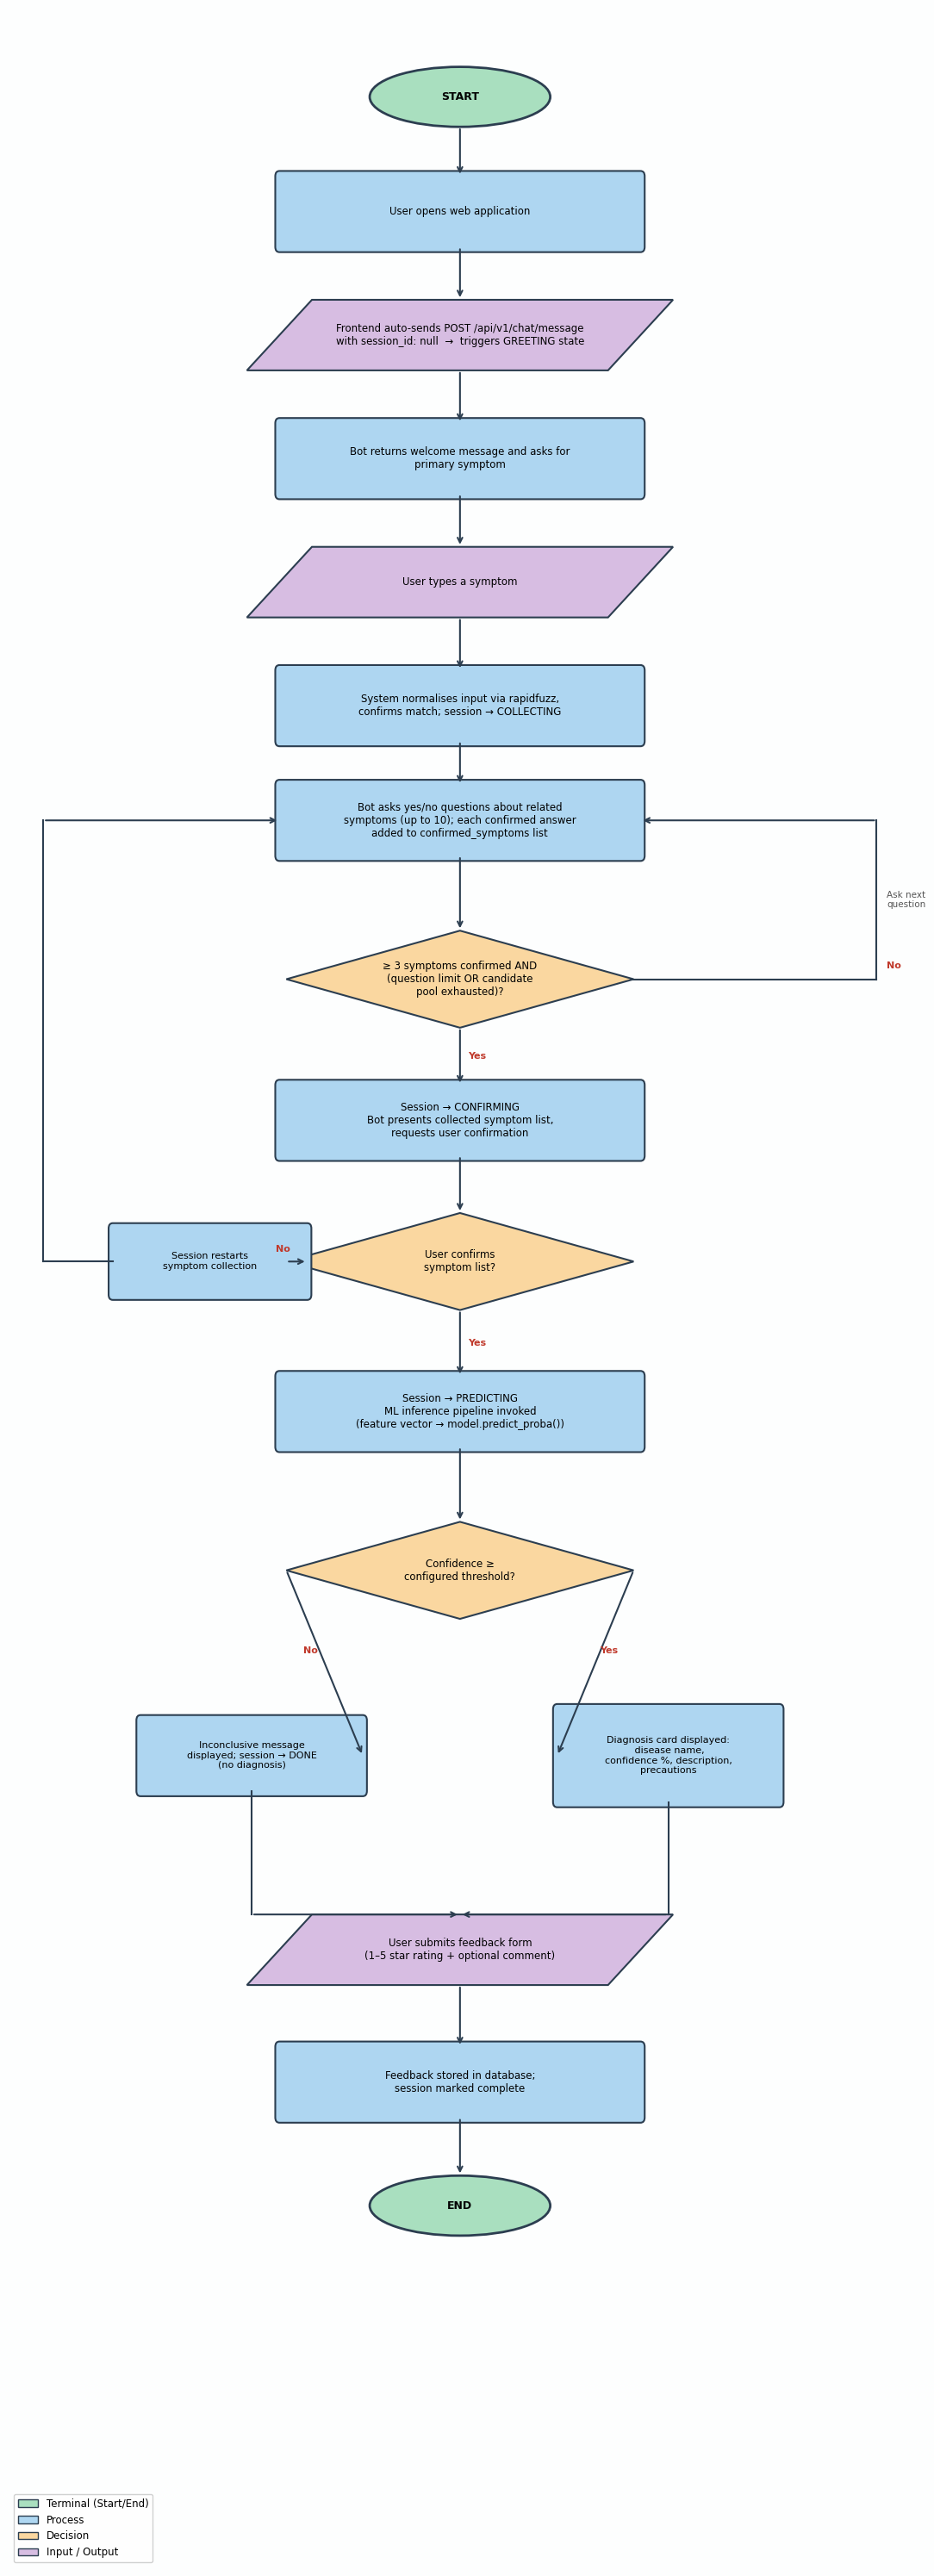

Saved: system_flowchart.png


In [4]:
fig, ax = plt.subplots(figsize=(11, 30))
ax.set_xlim(-6.5, 6.5)
ax.set_ylim(-14.0, 15.0)
ax.axis('off')
ax.set_facecolor(BG)
fig.patch.set_facecolor(BG)

RW, RH = 5.2, 0.80
DW, DH = 5.0, 1.10
OW, OH = 2.6, 0.68

# ── Nodes ───────────────────────────────────────────────────
s0  = terminal(ax,  0, 14.0, OW, OH, 'START')

s1  = process (ax,  0, 12.7, RW, RH,
               'User opens web application')

s2  = io_block(ax,  0, 11.3, RW, RH,
               'Frontend auto-sends POST /api/v1/chat/message\n'
               'with session_id: null  →  triggers GREETING state')

s3  = process (ax,  0,  9.9, RW, RH,
               'Bot returns welcome message and asks for\nprimary symptom')

s4  = io_block(ax,  0,  8.5, RW, RH,
               'User types a symptom')

s5  = process (ax,  0,  7.1, RW, RH,
               'System normalises input via rapidfuzz,\nconfirms match; session → COLLECTING')

s6  = process (ax,  0,  5.8, RW, RH,
               'Bot asks yes/no questions about related\nsymptoms (up to 10); each confirmed answer\nadded to confirmed_symptoms list',
               color=C_PROCESS)

s7  = decision(ax,  0,  4.0, DW, DH,
               '≥ 3 symptoms confirmed AND\n(question limit OR candidate\npool exhausted)?')

s8  = process (ax,  0,  2.4, RW, RH,
               'Session → CONFIRMING\nBot presents collected symptom list,\nrequests user confirmation')

s9  = decision(ax,  0,  0.8, DW, DH,
               'User confirms\nsymptom list?')

s9n = process (ax, -3.6,  0.8, 2.8, 0.75,
               'Session restarts\nsymptom collection', fs=8)

s10 = process (ax,  0, -0.9, RW, RH,
               'Session → PREDICTING\nML inference pipeline invoked\n(feature vector → model.predict_proba())')

s11 = decision(ax,  0, -2.7, DW, DH,
               'Confidence ≥\nconfigured threshold?')

s12a = process(ax,  3.0, -4.8, 3.2, 1.05,
               'Diagnosis card displayed:\n disease name,\nconfidence %, description,\nprecautions', fs=8)

s12b = process(ax, -3.0, -4.8, 3.2, 0.80,
               'Inconclusive message\ndisplayed; session → DONE\n(no diagnosis)', fs=8)

s13 = io_block(ax,  0, -7.0, RW, RH,
               'User submits feedback form\n(1–5 star rating + optional comment)')

s14 = process (ax,  0, -8.5, RW, RH,
               'Feedback stored in database;\nsession marked complete')

s_end = terminal(ax, 0, -9.9, OW, OH, 'END')

# ── Arrows ──────────────────────────────────────────────────
arr(ax, s0['bot'],  s1['top'])
arr(ax, s1['bot'],  s2['top'])
arr(ax, s2['bot'],  s3['top'])
arr(ax, s3['bot'],  s4['top'])
arr(ax, s4['bot'],  s5['top'])
arr(ax, s5['bot'],  s6['top'])
arr(ax, s6['bot'],  s7['top'])

arr(ax, s7['bot'],  s8['top'], label='Yes', lx=0.25)

x_loop = 6.0
ax.plot([s7['right'][0], x_loop], [s7['right'][1], s7['right'][1]],
        color=C_EDGE, lw=1.5, zorder=4)
ax.plot([x_loop, x_loop], [s7['right'][1], s6['right'][1]],
        color=C_EDGE, lw=1.5, zorder=4)
ax.annotate('', xy=s6['right'], xytext=(x_loop, s6['right'][1]),
            arrowprops=dict(arrowstyle='->', color=C_EDGE, lw=1.5), zorder=5)
ax.text(x_loop + 0.15, s7['right'][1] + 0.12, 'No', fontsize=8,
        color=C_LABEL, fontweight='bold')
ax.text(x_loop + 0.15, (s7['right'][1] + s6['right'][1])/2, 'Ask next\nquestion',
        fontsize=7.5, color='#555', ha='left', va='center')

arr(ax, s8['bot'],  s9['top'])

arr(ax, s9['left'],  s9n['right'], label='No', lx=-0.2, ly=0.14)
x_restart = -6.0
ax.plot([s9n['left'][0], x_restart], [s9n['left'][1], s9n['left'][1]],
        color=C_EDGE, lw=1.5, zorder=4)
ax.plot([x_restart, x_restart], [s9n['left'][1], s6['left'][1]],
        color=C_EDGE, lw=1.5, zorder=4)
ax.annotate('', xy=s6['left'], xytext=(x_restart, s6['left'][1]),
            arrowprops=dict(arrowstyle='->', color=C_EDGE, lw=1.5), zorder=5)

arr(ax, s9['bot'],  s10['top'], label='Yes', lx=0.25)

arr(ax, s10['bot'], s11['top'])

arr(ax, s11['right'], s12a['left'], label='Yes', lx=0.2, ly=0.14)
arr(ax, s11['left'],  s12b['right'], label='No', lx=-0.2, ly=0.14)

ax.plot([s12a['bot'][0], s12a['bot'][0]], [s12a['bot'][1], s13['top'][1]],
        color=C_EDGE, lw=1.5, zorder=4)
ax.annotate('', xy=s13['top'], xytext=(s12a['bot'][0], s13['top'][1]),
            arrowprops=dict(arrowstyle='->', color=C_EDGE, lw=1.5), zorder=5)

ax.plot([s12b['bot'][0], s12b['bot'][0]], [s12b['bot'][1], s13['top'][1]],
        color=C_EDGE, lw=1.5, zorder=4)
ax.annotate('', xy=s13['top'], xytext=(s12b['bot'][0], s13['top'][1]),
            arrowprops=dict(arrowstyle='->', color=C_EDGE, lw=1.5), zorder=5)

arr(ax, s13['bot'],  s14['top'])
arr(ax, s14['bot'],  s_end['top'])

# ── Legend ──────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(facecolor=C_TERMINAL, edgecolor=C_EDGE, label='Terminal (Start/End)'),
    mpatches.Patch(facecolor=C_PROCESS,  edgecolor=C_EDGE, label='Process'),
    mpatches.Patch(facecolor=C_DECISION, edgecolor=C_EDGE, label='Decision'),
    mpatches.Patch(facecolor=C_IO,       edgecolor=C_EDGE, label='Input / Output'),
]
ax.legend(handles=legend_items, loc='lower left', fontsize=8.5, framealpha=0.9)

plt.tight_layout()
plt.savefig('system_flowchart.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved: system_flowchart.png')